In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

# Data Preprocessing

In [27]:
df = pd.read_excel('data_ML.xlsx')
df.head()

,C,H,N,O,MaxPartialCharge,MinPartialCharge,BCUT2D_LOGPLOW,BCUT2D_LOGPHI,BCUT2D_CHGHI,BCUT2D_MRLOW,...,NumRotatableBonds,BalabanJ,Kappa1,NumHAcceptors,Input Formation Enthalpy (kJ/mol),N(mol/g),M(g/mol),HOT(J/g),veloci(km/s),press(Gpa)
0,12,16,8,12,0.294019,-0.383868,-3.486647,3.184143,3.399440,-0.842051,...,12,1.665643,20.537557,14,2063.182511,0.03015,24.57,10305.98,8.92,34.36
1,10,13,7,10,0.293995,-0.384062,-3.534271,3.123573,3.427110,-0.820235,...,8,1.650393,16.564749,12,1801.040134,0.03003,24.85,10381.51,9.06,35.89
2,10,12,4,10,0.293995,-0.383940,-3.512661,3.129898,3.426237,-0.841134,...,6,1.626162,14.498584,11,1255.198155,0.02872,25.2,10031.99,8.83,34.1
3,10,12,8,6,0.183110,-0.382566,-3.542917,3.117207,3.419354,-0.792458,...,5,1.806522,14.068647,10,2059.781470,0.02939,22,10318.64,8.4,29.95
4,10,13,5,9,0.293995,-0.383701,-3.522992,3.123978,3.416772,-0.819032,...,6,1.626162,14.498584,11,1446.475544,0.02952,23.61,10109.62,8.66,32.35


In [28]:
df.columns

Index(['C', 'H', 'N', 'O', 'MaxPartialCharge', 'MinPartialCharge',
       'BCUT2D_LOGPLOW', 'BCUT2D_LOGPHI', 'BCUT2D_CHGHI', 'BCUT2D_MRLOW',
       'BCUT2D_MWHI', 'FpDensityMorgan1', 'FpDensityMorgan3', 'MolLogP', 'qed',
       'MinEStateIndex', 'TPSA', 'HallKierAlpha', 'NOCount', 'BertzCT',
       'MinAbsEStateIndex', 'NumHeteroatoms', 'Kappa3', 'NumRotatableBonds',
       'BalabanJ', 'Kappa1', 'NumHAcceptors',
       'Input Formation Enthalpy (kJ/mol)', 'N(mol/g)', 'M(g/mol)', 'HOT(J/g)',
       'veloci(km/s)', 'press(Gpa)'],
      dtype='object')

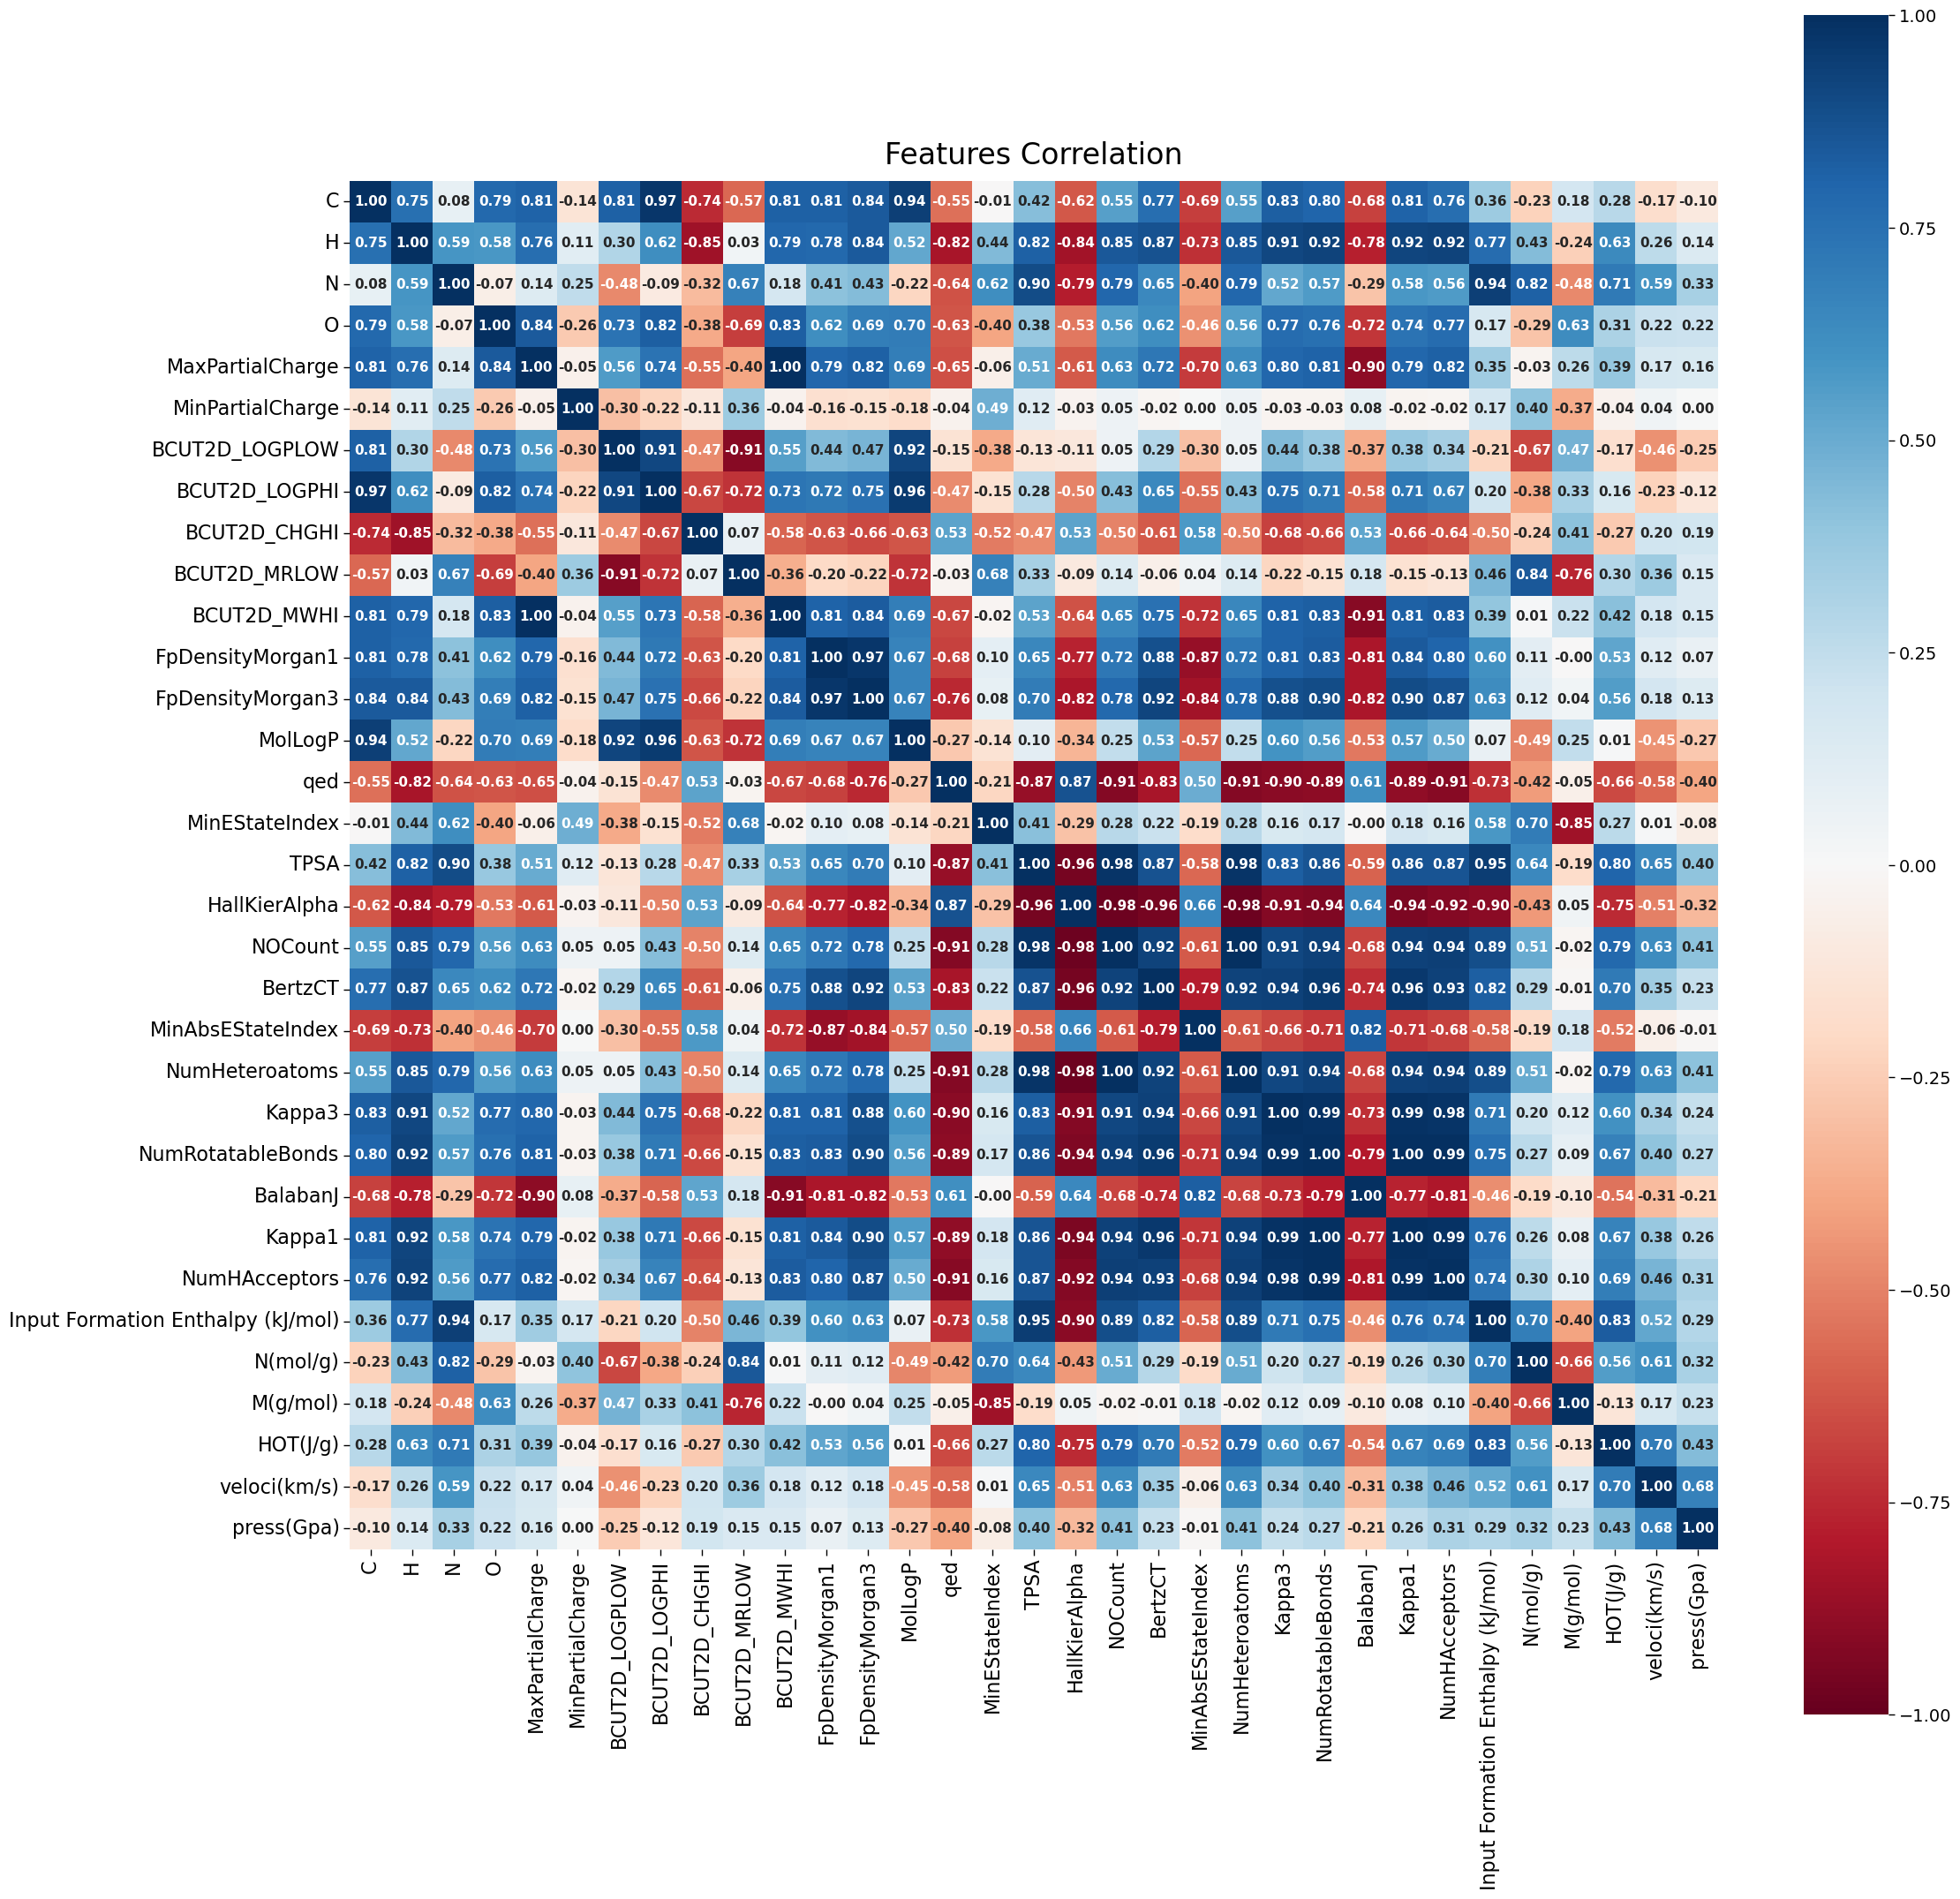

In [29]:
sns.set_context("paper", rc={"axes.labelsize":20})
fig, ax = plt.subplots(figsize=(25,25))  
heatmap = sns.heatmap(df.corr(), annot=True, annot_kws={'fontsize':11, 'fontweight':'bold'}, 
            cmap='RdBu', vmin=-1, vmax=1, square=True, fmt='0.2f', ax=ax)
heatmap.set_title('Features Correlation', fontdict={'fontsize':24}, pad=14)
heatmap.set_xticklabels(heatmap.get_xmajorticklabels(), fontsize = 16)
heatmap.set_yticklabels(heatmap.get_ymajorticklabels(), fontsize = 16)

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

In [30]:
X = df.iloc[:,:27]
Y = df.iloc[:,27:]

In [31]:
X.head()

,C,H,N,O,MaxPartialCharge,MinPartialCharge,BCUT2D_LOGPLOW,BCUT2D_LOGPHI,BCUT2D_CHGHI,BCUT2D_MRLOW,...,HallKierAlpha,NOCount,BertzCT,MinAbsEStateIndex,NumHeteroatoms,Kappa3,NumRotatableBonds,BalabanJ,Kappa1,NumHAcceptors
0,12,16,8,12,0.294019,-0.383868,-3.486647,3.184143,3.399440,-0.842051,...,-3.36,20,1045.469395,0.427150,20,1.058323,12,1.665643,20.537557,14
1,10,13,7,10,0.293995,-0.384062,-3.534271,3.123573,3.427110,-0.820235,...,-2.60,17,863.556007,0.477749,17,0.715287,8,1.650393,16.564749,12
2,10,12,4,10,0.293995,-0.383940,-3.512661,3.129898,3.426237,-0.841134,...,-1.84,14,755.600538,0.517893,14,0.530079,6,1.626162,14.498584,11
3,10,12,8,6,0.183110,-0.382566,-3.542917,3.117207,3.419354,-0.792458,...,-2.31,14,862.776644,0.431226,14,0.480119,5,1.806522,14.068647,10
4,10,13,5,9,0.293995,-0.383701,-3.522992,3.123978,3.416772,-0.819032,...,-1.84,14,756.680854,0.392893,14,0.530079,6,1.626162,14.498584,11


In [32]:
Y.head()

,Input Formation Enthalpy (kJ/mol),N(mol/g),M(g/mol),HOT(J/g),veloci(km/s),press(Gpa)
0,2063.182511,0.03015,24.57,10305.98,8.92,34.36
1,1801.040134,0.03003,24.85,10381.51,9.06,35.89
2,1255.198155,0.02872,25.2,10031.99,8.83,34.1
3,2059.781470,0.02939,22,10318.64,8.4,29.95
4,1446.475544,0.02952,23.61,10109.62,8.66,32.35


In [33]:
X = X.values
Y = Y.values

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((89, 27), (23, 27), (89, 6), (23, 6))

# Model training

In [35]:
pca = PCA(n_components=10)
X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)
X_train_reduced.shape, X_test_reduced.shape

((89, 10), (23, 10))

In [41]:
lr = LinearRegression()
lr.fit(X_train_reduced, y_train)
#lr = RandomForestRegressor()
#lr.fit(X_train_reduced, y_train)


LinearRegression()

# Model testing

In [42]:
y_pred = lr.predict(X_test_reduced)

In [43]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
explained_var = explained_variance_score(y_test, y_pred)

In [44]:
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Explained Variance: {explained_var:.4f}")

MAE: 27.2355
MSE: 8092.5261
RMSE: 89.9585
R²: 0.9284
Explained Variance: 0.9321


# Learning curve

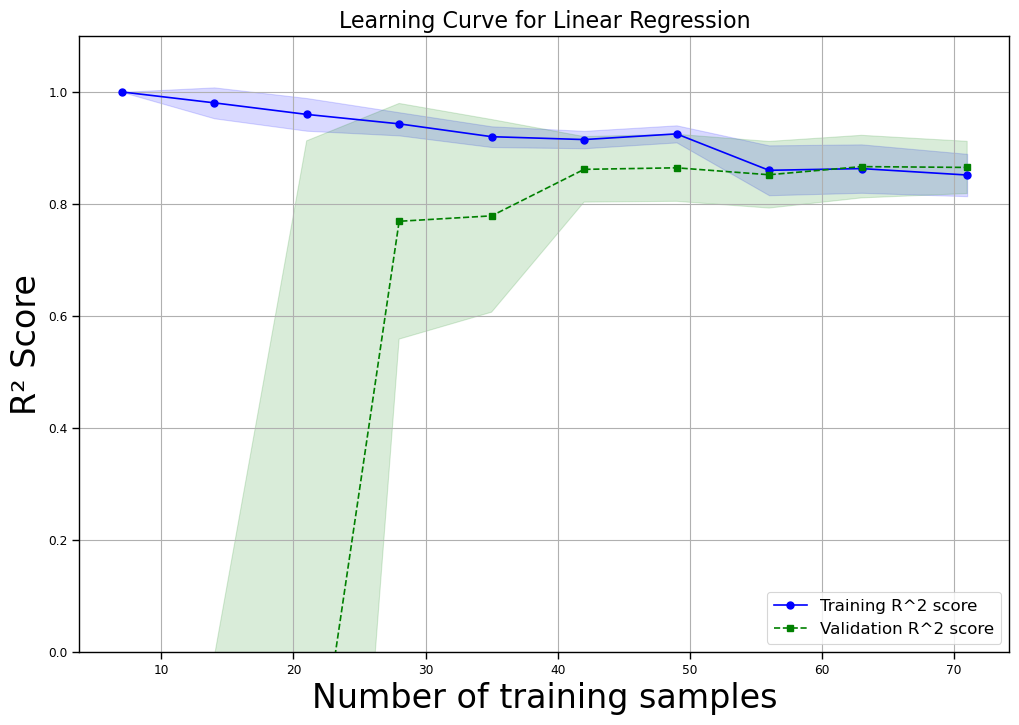

In [45]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=lr,
    X=X_train_reduced,
    y=y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(12, 8))

plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training R^2 score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Validation R^2 score')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='green')

plt.title('Learning Curve for Linear Regression', fontsize=16)
plt.xlabel('Number of training samples', fontsize=24)
plt.ylabel('R² Score', fontsize=24)
plt.grid()
plt.legend(loc='lower right', fontsize=12)
plt.ylim([0.0, 1.1])

plt.show()
